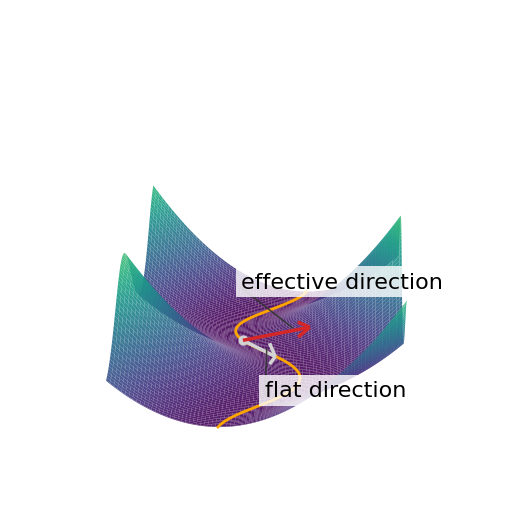

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Valley coordinates: x runs along the valley, y is transverse.
x = np.linspace(-8.0, 8.0, 320)
y = np.linspace(-3.2, 3.2, 240)
X, Y = np.meshgrid(x, y)

# Meandering valley centerline.
center = 0.85 * np.sin(0.55 * X)

# Flatter valley floor.
floor = 0.008 * np.cos(0.7 * X) + 0.003 * np.sin(1.1 * X) + 0.002 * X

# Valley surface.
Z = 0.07 * (Y - center)**2 + floor
Zmin = Z.min()
Z = Z - Zmin

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d', proj_type='persp', computed_zorder=False)
ax.set_position([0.0, 0.0, 1.0, 1.0])
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=0, antialiased=True, alpha=0.92, cmap='viridis', vmin=Z.min(), vmax=Z.max() * 1.45, zorder=0)

# Valley bottom curve.
x_line = np.linspace(-8.0, 8.0, 800)
y_line = 0.85 * np.sin(0.55 * x_line)
z_line_raw = 0.008 * np.cos(0.7 * x_line) + 0.003 * np.sin(1.1 * x_line) + 0.002 * x_line
z_line = z_line_raw - Zmin
ax.plot(x_line, y_line, z_line, linewidth=2, color='orange', zorder=2)

# -----------------------------
# Base point on the valley bottom
# -----------------------------
x0 = -1.5
y0 = 0.85 * np.sin(0.55 * x0)
z0_raw = 0.008 * np.cos(0.7 * x0) + 0.003 * np.sin(1.1 * x0) + 0.002 * x0
z0 = z0_raw - Zmin

# Mark the base point
ax.scatter([x0], [y0], [z0], color="lightgray", s=40, zorder=8)

# -----------------------------
# Flat direction:
# move along the valley bottom with small change
# -----------------------------
dx_flat = 1.5
x1 = x0 + dx_flat
y1 = 0.85 * np.sin(0.55 * x1)
z1_raw = 0.008 * np.cos(0.7 * x1) + 0.003 * np.sin(1.1 * x1) + 0.002 * x1
z1 = z1_raw - Zmin

vx_flat = x1 - x0
vy_flat = y1 - y0
vz_flat = z1 - z0

ax.quiver(
    x0, y0, z0,
    vx_flat, vy_flat, vz_flat,
    length=1.35,
    arrow_length_ratio=0.18,
    linewidth=2.5,
    color='lightgray',
    zorder=10
)

flat_label_x = x1 + 1.5
flat_label_y = y1 - 0.0
flat_label_z = z1 - 0.3

ax.plot(
    [x1, flat_label_x], [y1, flat_label_y], [z1 + 0.03, flat_label_z],
    color='0.2',
    linewidth=1.1,
    alpha=0.9,
    zorder=10.5
)

ax.text(
    flat_label_x, flat_label_y, flat_label_z,
    'flat direction',
    fontsize=16,
    color='black',
    bbox=dict(
        # boxstyle='round,pad=0.28', 
        facecolor='white', 
        # edgecolor='0.25', 
        linewidth=0.0, 
        alpha=0.8
    ),
    zorder=11
)

# -----------------------------
# Sensitive direction:
# move up the valley wall with larger change
# -----------------------------
dy_sensitive = 1.2
x2 = x0
y2 = y0 + dy_sensitive
center_x0 = 0.85 * np.sin(0.55 * x0)
floor_x0 = 0.008 * np.cos(0.7 * x0) + 0.003 * np.sin(1.1 * x0) + 0.002 * x0
z2 = 0.07 * (y2 - center_x0)**2 + floor_x0 - Zmin

vx_sensitive = x2 - x0
vy_sensitive = y2 - y0
vz_sensitive = z2 - z0

ax.quiver(
    x0, y0, z0,
    vx_sensitive, vy_sensitive, vz_sensitive,
    length=1.35,
    arrow_length_ratio=0.18,
    linewidth=2.5,
    color='tab:red',
    zorder=10
)

sensitive_label_x = x2 + 1.00
sensitive_label_y = y2 - 1.2
sensitive_label_z = z2 + 0.5

ax.plot(
    [x2, sensitive_label_x], [y2, sensitive_label_y], [z2 + 0.03, sensitive_label_z],
    color='0.2',
    linewidth=1.1,
    alpha=0.9,
    zorder=10.5
)

ax.text(
    sensitive_label_x, sensitive_label_y, sensitive_label_z,
    'effective direction',
    fontsize=16,
    color='black',
    bbox=dict(
        # boxstyle='round,pad=0.28', 
        facecolor='white', 
        # edgecolor='white', 
        linewidth=0.0, 
        alpha=0.8
    ),
    zorder=11
)

# View / layout
ax.set_xlim(-8.0, 8.0)
ax.set_ylim(-3.0, 3.0)
ax.set_zlim(0.0, 2.0)
ax.set_box_aspect((2.7, 1.2, 1.0), zoom=1.28)
ax.view_init(elev=12, azim=2)

# Hide axes
ax.set_axis_off()

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()